In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


In [5]:
data = pd.read_csv('/content/Mobile Price Prediction Datatset.csv')
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     836 non-null    int64  
 1   Brand me       836 non-null    object 
 2   Ratings        805 non-null    float64
 3   RAM            829 non-null    float64
 4   ROM            832 non-null    float64
 5   Mobile_Size    834 non-null    float64
 6   Primary_Cam    836 non-null    int64  
 7   Selfi_Cam      567 non-null    float64
 8   Battery_Power  836 non-null    int64  
 9   Price          836 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 65.4+ KB
None


In [6]:
# ============================================================
# DATASET EXPLORATION
# ============================================================

print("Rows and Columns:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nFirst 5 Rows:")
print(data.head())

print("\nStatistical Description:")
print(data.describe())

Rows and Columns: (836, 10)

Column Names:
['Unnamed: 0', 'Brand me', 'Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power', 'Price']

First 5 Rows:
   Unnamed: 0                         Brand me  Ratings  RAM    ROM  \
0           0            LG V30+ (Black, 128 )      4.3  4.0  128.0   
1           1                       I Kall K11      3.4  6.0   64.0   
2           2                     Nokia 105 ss      4.3  4.0    4.0   
3           3  Samsung Galaxy A50 (White, 64 )      4.4  6.0   64.0   
4           4       POCO F1 (Steel Blue, 128 )      4.5  6.0  128.0   

   Mobile_Size  Primary_Cam  Selfi_Cam  Battery_Power  Price  
0         6.00           48       13.0           4000  24999  
1         4.50           48       12.0           4000  15999  
2         4.50           64       16.0           4000  15000  
3         6.40           48       15.0           3800  18999  
4         6.18           35       15.0           3800  18999  

Statistical Des

In [7]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
Unnamed: 0         0
Brand me           0
Ratings           31
RAM                7
ROM                4
Mobile_Size        2
Primary_Cam        0
Selfi_Cam        269
Battery_Power      0
Price              0
dtype: int64


In [10]:
# ============================================================
# REMOVE UNNECESSARY INDEX COLUMN
# ============================================================

data = data.drop(columns=['Unnamed: 0'], errors='ignore')

print("\nDataset Shape After Removing Unnecessary Column:")
print(data.shape)


Dataset Shape After Removing Unnecessary Column:
(836, 9)


In [11]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

small_missing_cols = [
    'Ratings',
    'RAM',
    'ROM',
    'Mobile_Size'
]

for col in small_missing_cols:
    data[col] = data[col].fillna(data[col].median())


data['Selfi_Cam'] = data['Selfi_Cam'].fillna(
    data['Selfi_Cam'].median()
)


print("\nMissing Values After Imputation:")
print(data.isnull().sum())

print(
    "\nTotal Missing Values:",
    data.isnull().sum().sum()
)




Missing Values After Imputation:
Brand me         0
Ratings          0
RAM              0
ROM              0
Mobile_Size      0
Primary_Cam      0
Selfi_Cam        0
Battery_Power    0
Price            0
dtype: int64

Total Missing Values: 0


In [12]:
# ============================================================
# REMOVE DUPLICATE ROWS
# ============================================================

print(
    "\nDuplicate Rows:",
    data.duplicated().sum()
)

data = data.drop_duplicates()

print(
    "Duplicates After Removal:",
    data.duplicated().sum()
)



Duplicate Rows: 221
Duplicates After Removal: 0


In [13]:
# ============================================================
# OUTLIER DETECTION
# ============================================================

numeric_cols = [
    'Ratings',
    'RAM',
    'ROM',
    'Mobile_Size',
    'Primary_Cam',
    'Selfi_Cam',
    'Battery_Power',
    'Price'
]

for col in numeric_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower) |
        (data[col] > upper)
    ]

    print(
        col,
        ":",
        len(outliers),
        "potential outliers"
    )


print(
    "\nDataset shape after outlier detection:",
    data.shape
)

Ratings : 2 potential outliers
RAM : 274 potential outliers
ROM : 114 potential outliers
Mobile_Size : 8 potential outliers
Primary_Cam : 270 potential outliers
Selfi_Cam : 63 potential outliers
Battery_Power : 65 potential outliers
Price : 51 potential outliers

Dataset shape after outlier detection: (615, 9)


In [14]:
# ============================================================
# TEXT CLEANING
# ============================================================

data['Brand me'] = data['Brand me'].astype(str).str.strip()


In [15]:
# ============================================================
# FINAL DATA VERIFICATION
# ============================================================

print(
    "\nTotal Missing Values:",
    data.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    data.duplicated().sum()
)

print(
    "Final Dataset Shape:",
    data.shape
)

print("\nFirst 5 Rows After Cleaning:")
print(data.head())

print("\nFinal Statistical Description:")
print(data.describe())



Total Missing Values: 0
Duplicate Rows: 0
Final Dataset Shape: (615, 9)

First 5 Rows After Cleaning:
                          Brand me  Ratings  RAM    ROM  Mobile_Size  \
0            LG V30+ (Black, 128 )      4.3  4.0  128.0         6.00   
1                       I Kall K11      3.4  6.0   64.0         4.50   
2                     Nokia 105 ss      4.3  4.0    4.0         4.50   
3  Samsung Galaxy A50 (White, 64 )      4.4  6.0   64.0         6.40   
4       POCO F1 (Steel Blue, 128 )      4.5  6.0  128.0         6.18   

   Primary_Cam  Selfi_Cam  Battery_Power  Price  
0           48       13.0           4000  24999  
1           48       12.0           4000  15999  
2           64       16.0           4000  15000  
3           48       15.0           3800  18999  
4           35       15.0           3800  18999  

Final Statistical Description:
          Ratings         RAM         ROM  Mobile_Size  Primary_Cam  \
count  615.000000  615.000000  615.000000   615.000000   615.

In [16]:

# ============================================================
# SAVE CLEANED DATASET
# ============================================================

cleaned_file = (
    '/content/drive/MyDrive/'
    'cleaned_mobile_phone_dataset.csv'
)

data.to_csv(
    cleaned_file,
    index=False
)

print("\nCleaned dataset saved successfully!")
print(cleaned_file)


Cleaned dataset saved successfully!
/content/drive/MyDrive/cleaned_mobile_phone_dataset.csv


In [17]:
# ============================================================
# BRAND EXTRACTION
# ============================================================

brands = [
    'Samsung', 'Apple', 'OnePlus', 'Xiaomi', 'Redmi', 'POCO',
    'Realme', 'OPPO', 'Vivo', 'Nokia', 'Motorola', 'LG',
    'Honor', 'Huawei', 'Google', 'Infinix', 'Tecno', 'Lava',
    'Karbonn', 'Micromax', 'I Kall', 'Itel', 'Jivi',
    'Kechaoda', 'InFocus', 'Alcatel', 'Lenovo', 'Black Shark',
    'iQOO', 'Meizu', 'Yuho', 'Salora', 'Easyfone', 'MTR',
    'Micax', 'GAMMA', 'Snexian', 'Blacear', 'Blacerry',
    'Ssky', 'Jmax', 'Muphone', 'Detel', 'Peace', 'Forme',
    'Gee', 'Hicell', 'Gfive', 'Ecotel', 'GreenBerry',
    'Trio', 'Tork', 'Mafe', 'Dublin', 'Megus', 'Wizphone',
    'Callbar', 'Good One', 'BlackZone', 'Nexus'
]


def extract_brand(model):

    model = str(model).strip()

    for brand in sorted(
        brands,
        key=len,
        reverse=True
    ):

        if model.lower().startswith(
            brand.lower()
        ):
            return brand

    return "Other"


data['Brand'] = data['Brand me'].apply(
    extract_brand
)

print("\nBrand Extraction:")
print(
    data[['Brand me', 'Brand']].head(20)
)




Brand Extraction:
                                       Brand me     Brand
0                         LG V30+ (Black, 128 )        LG
1                                    I Kall K11    I Kall
2                                  Nokia 105 ss     Nokia
3               Samsung Galaxy A50 (White, 64 )   Samsung
4                    POCO F1 (Steel Blue, 128 )      POCO
5        Apple iPhone 11 Pro (Space Grey, 512 )     Apple
6   Samsung Galaxy A70s (Prism Crush Red, 128 )   Samsung
7    Samsung Galaxy S10 Lite (Prism Blue, 512 )   Samsung
8                  OPPO A9 (Marble Green, 128 )      OPPO
9                POCO F1 (Graphite Black, 256 )      POCO
10                                  Megus Ultra     Megus
11                          Jmax M40 Coo of Two      Jmax
12                     Wizphone WP (Black, 16 )  Wizphone
13                                Easyfone Star  Easyfone
14            OnePlus 7 Pro (Nebula Blue, 256 )   OnePlus
15            OnePlus 7 Pro (Mirror Grey, 128 )   One

In [18]:
# ============================================================
# SPECIFICATION SUMMARY
# ============================================================

summary = pd.DataFrame({

    'Specification': [
        'RAM (GB)',
        'Storage (GB)',
        'Battery (mAh)',
        'Price'
    ],

    'Average': [
        data['RAM'].mean(),
        data['ROM'].mean(),
        data['Battery_Power'].mean(),
        data['Price'].mean()
    ]
})

print("\nSpecification Summary:")
print(summary)



Specification Summary:
   Specification       Average
0       RAM (GB)      6.104065
1   Storage (GB)     61.907967
2  Battery (mAh)   3259.853659
3          Price  17929.458537


In [19]:
# ============================================================
# BRAND-WISE ANALYSIS
# ============================================================

brand_analysis = data.groupby('Brand').agg({
    'RAM': 'mean',
    'ROM': 'mean',
    'Battery_Power': 'mean',
    'Price': 'mean'
}).round(2)

print("\nBrand-wise Analysis:")
print(brand_analysis)


Brand-wise Analysis:
              RAM     ROM  Battery_Power      Price
Brand                                              
Alcatel      2.00   20.00        2900.00    8196.75
Apple        9.03   80.52        3745.16  148098.77
Blacear      7.54   40.62        1615.38    1186.85
Blacerry     4.00   64.00        3800.00   24999.00
Black Shark  6.00  128.00        3800.00   31999.00
BlackZone    7.00   48.00        2916.67     765.33
Callbar      0.00   64.00        3000.00     595.00
Detel        6.00   32.00        3000.00     647.00
Dublin       6.00   64.00        2800.00     649.00
Easyfone     6.00   32.00        3321.43    3499.07
Ecotel       6.00   20.00        3000.00     599.00
Forme        9.00   23.50        1925.00     874.00
GAMMA        6.00   32.00        3000.00     976.33
Gee          3.40   28.80        3588.00   11616.80
Gfive        9.00   48.00        2025.00     894.00
Good One     6.00   32.00        3266.67    1465.67
Google       4.00   64.00        3000.00  

In [20]:
# ============================================================
# PRICE CATEGORIES
# ============================================================

def price_category(price):

    if price < 10000:
        return "Budget"

    elif price < 20000:
        return "Mid-Range"

    elif price < 40000:
        return "Premium"

    else:
        return "Flagship"


data['Price_Category'] = data['Price'].apply(
    price_category
)

print("\nPrice Categories:")
print(
    data[
        ['Brand me', 'Price', 'Price_Category']
    ].head(20)
)

print("\nPrice Category Counts:")
print(
    data['Price_Category'].value_counts()
)




Price Categories:
                                       Brand me   Price Price_Category
0                         LG V30+ (Black, 128 )   24999        Premium
1                                    I Kall K11   15999      Mid-Range
2                                  Nokia 105 ss   15000      Mid-Range
3               Samsung Galaxy A50 (White, 64 )   18999      Mid-Range
4                    POCO F1 (Steel Blue, 128 )   18999      Mid-Range
5        Apple iPhone 11 Pro (Space Grey, 512 )  140300       Flagship
6   Samsung Galaxy A70s (Prism Crush Red, 128 )   29999        Premium
7    Samsung Galaxy S10 Lite (Prism Blue, 512 )   47999       Flagship
8                  OPPO A9 (Marble Green, 128 )   16490      Mid-Range
9                POCO F1 (Graphite Black, 256 )   22999        Premium
10                                  Megus Ultra    1099         Budget
11                          Jmax M40 Coo of Two    1299         Budget
12                     Wizphone WP (Black, 16 )    5498   

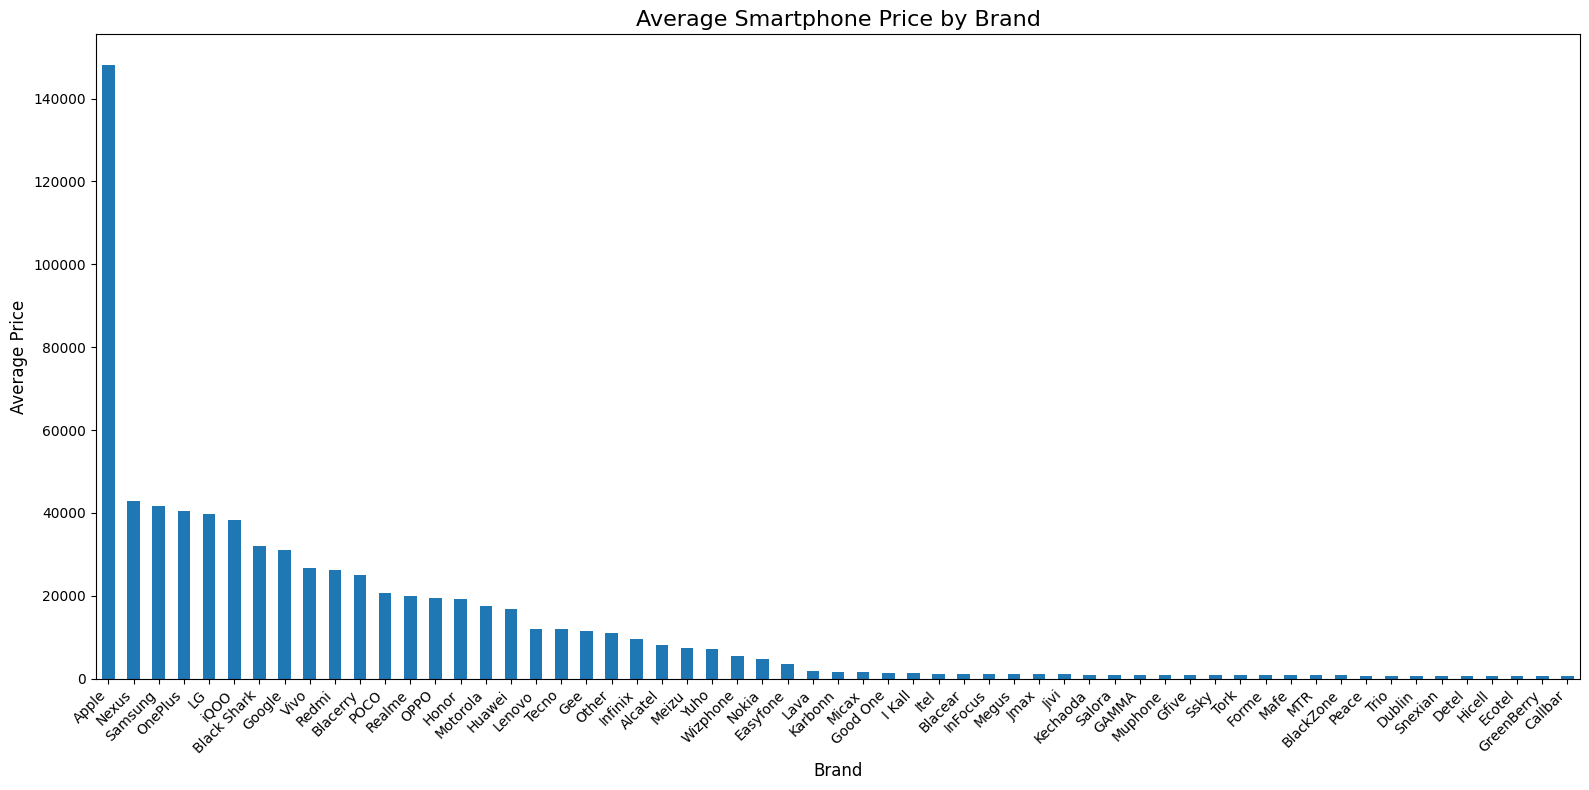

In [22]:
# ============================================================
# BAR CHART - AVERAGE SMARTPHONE PRICE BY BRAND
# ============================================================

brand_price = (
    data.groupby('Brand')['Price']
    .mean()
    .sort_values(ascending=False)
)

# Create the figure
plt.figure(figsize=(16, 8))

# Create bar chart
brand_price.plot(kind='bar')

# Add title and axis labels
plt.title('Average Smartphone Price by Brand', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Price', fontsize=12)

# Arrange X-axis labels neatly
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add space around the chart
plt.tight_layout()

# Display chart
plt.show()

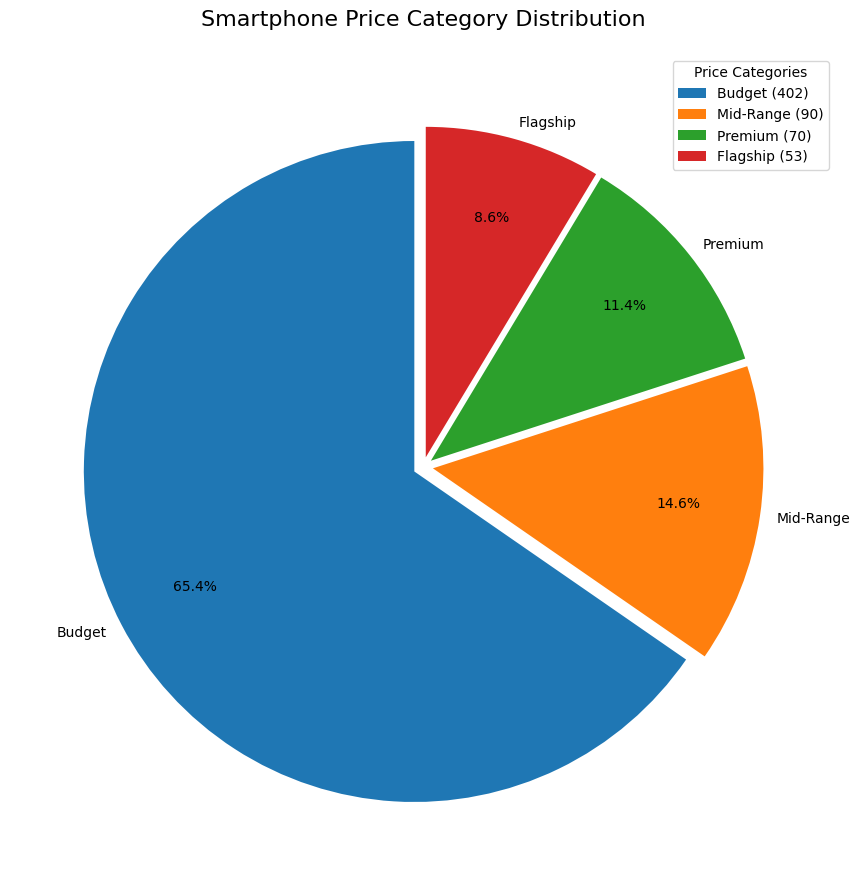

In [33]:
# ============================================================
# PIE CHART - SMARTPHONE PRICE CATEGORY DISTRIBUTION
# ============================================================

price_counts = data['Price_Category'].value_counts()

plt.figure(figsize=(9, 9))

plt.pie(
    price_counts.values,
    labels=price_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.03] * len(price_counts),
    pctdistance=0.75,
    labeldistance=1.05
)

plt.title(
    'Smartphone Price Category Distribution',
    fontsize=16,
    pad=20
)

# Add legend with category counts
legend_labels = [
    f'{category} ({count})'
    for category, count in price_counts.items()
]

plt.legend(
    legend_labels,
    title='Price Categories',
    loc='best'
)

plt.tight_layout()

plt.show()

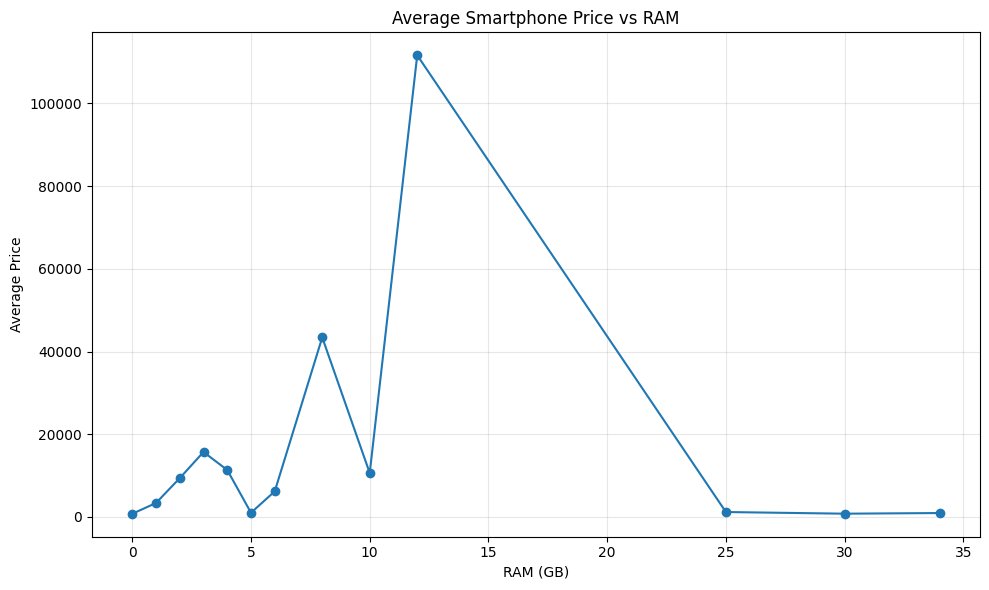

In [24]:
# ============================================================
# LINE CHART
# ============================================================

ram_price = (
    data.groupby('RAM')['Price']
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    ram_price.index,
    ram_price.values,
    marker='o'
)

plt.title(
    'Average Smartphone Price vs RAM'
)

plt.xlabel('RAM (GB)')
plt.ylabel('Average Price')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

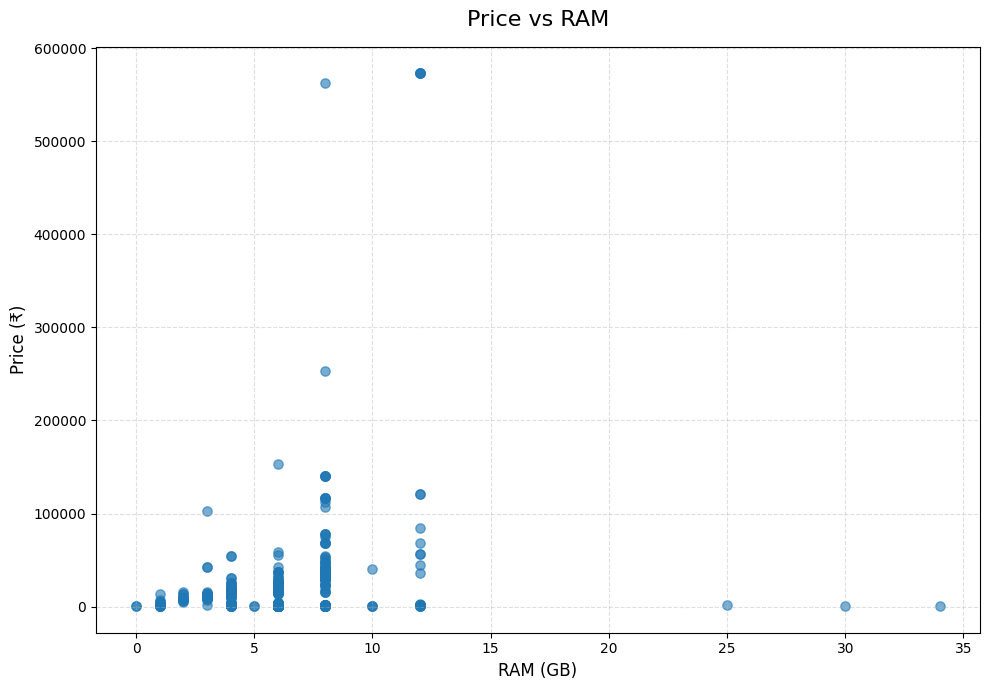

In [35]:
# ============================================================
# SCATTER PLOT - PRICE VS RAM
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    data['RAM'],
    data['Price'],
    alpha=0.6,
    s=45
)

plt.title(
    'Price vs RAM',
    fontsize=16,
    pad=15
)

plt.xlabel(
    'RAM (GB)',
    fontsize=12
)

plt.ylabel(
    'Price (₹)',
    fontsize=12
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()

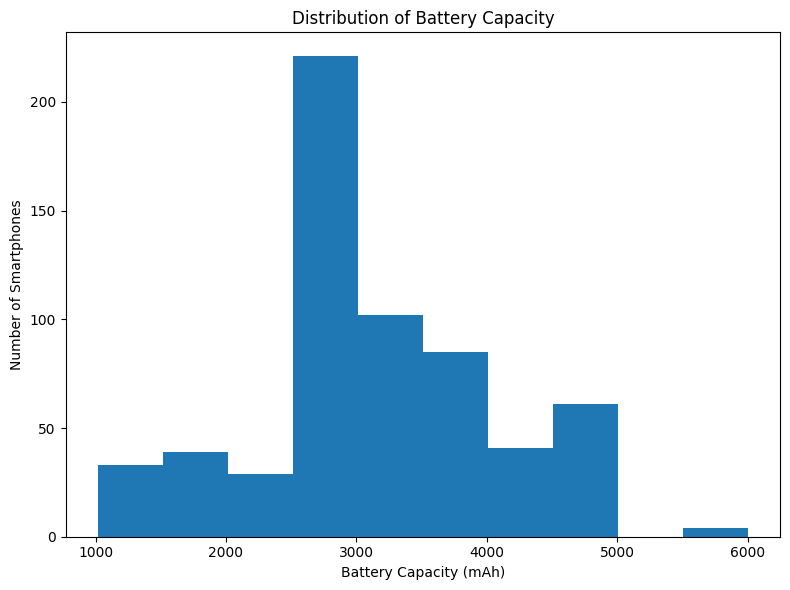

In [26]:
# ============================================================
# HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    data['Battery_Power'],
    bins=10
)

plt.title(
    'Distribution of Battery Capacity'
)

plt.xlabel(
    'Battery Capacity (mAh)'
)

plt.ylabel(
    'Number of Smartphones'
)

plt.tight_layout()

plt.show()


In [29]:
# ============================================================
# MOBILE PHONE RECOMMENDATION SYSTEM
# ============================================================

print(
    "\n===== MOBILE PHONE RECOMMENDATION SYSTEM ====="
)

budget = float(
    input("Enter your maximum budget (₹): ")
)

min_ram = float(
    input("Enter minimum RAM required (GB): ")
)

min_storage = float(
    input("Enter minimum storage required (GB): ")
)

min_battery = float(
    input("Enter minimum battery required (mAh): ")
)


recommended = data[
    (data['Price'] <= budget) &
    (data['RAM'] >= min_ram) &
    (data['ROM'] >= min_storage) &
    (data['Battery_Power'] >= min_battery)
]


print(
    "\n===== RECOMMENDED MOBILE PHONES ====="
)


if len(recommended) == 0:

    print(
        "Sorry! No mobile phone matches all your requirements."
    )

else:

    recommended = recommended.sort_values(
        by='Price'
    )

    print(
        recommended[
            [
                'Brand me',
                'RAM',
                'ROM',
                'Battery_Power',
                'Price'
            ]
        ].to_string(index=False)
    )



===== MOBILE PHONE RECOMMENDATION SYSTEM =====
Enter your maximum budget (₹): 30000
Enter minimum RAM required (GB): 4
Enter minimum storage required (GB): 64
Enter minimum battery required (mAh): 4000

===== RECOMMENDED MOBILE PHONES =====
                                     Brand me  RAM   ROM  Battery_Power  Price
                                   I Kall K11  6.0  64.0           4700    599
                                  MTR Ferrari  8.0  64.0           5000   1275
              Infinix Hot 9 (Ocean Wave, 64 )  4.0  64.0           5000   9499
       Tecno Spark Power 2 (Ice Jadeite, 64 )  4.0  64.0           6000   9999
        Tecno Spark Power 2 (Misty Grey, 64 )  4.0  64.0           6000   9999
             Realme rzo 10 (That White, 128 )  4.0 128.0           5000  11999
              Realme rzo 10 (That Blue, 128 )  4.0 128.0           5000  11999
             Realme rzo 10 (That Green, 128 )  4.0 128.0           5000  11999
                OPPO A31 (Fantasy White, 64 )  

In [30]:
# ============================================================
# EXACT + NEAR MATCHING MOBILE PHONES
# ============================================================

exact_matches = data[
    (data['Price'] <= budget) &
    (data['RAM'] >= min_ram) &
    (data['ROM'] >= min_storage) &
    (data['Battery_Power'] >= min_battery)
]


print("\n===== EXACT MATCHES =====")


if len(exact_matches) == 0:

    print("No exact matches found.")

else:

    print(
        exact_matches[
            [
                'Brand me',
                'RAM',
                'ROM',
                'Battery_Power',
                'Price'
            ]
        ]
        .sort_values('Price')
        .to_string(index=False)
    )



===== EXACT MATCHES =====
                                     Brand me  RAM   ROM  Battery_Power  Price
                                   I Kall K11  6.0  64.0           4700    599
                                  MTR Ferrari  8.0  64.0           5000   1275
              Infinix Hot 9 (Ocean Wave, 64 )  4.0  64.0           5000   9499
       Tecno Spark Power 2 (Ice Jadeite, 64 )  4.0  64.0           6000   9999
        Tecno Spark Power 2 (Misty Grey, 64 )  4.0  64.0           6000   9999
             Realme rzo 10 (That White, 128 )  4.0 128.0           5000  11999
              Realme rzo 10 (That Blue, 128 )  4.0 128.0           5000  11999
             Realme rzo 10 (That Green, 128 )  4.0 128.0           5000  11999
                OPPO A31 (Fantasy White, 64 )  4.0  64.0           4230  12490
                 Vivo Y15 (Burgundy Red, 64 )  4.0  64.0           5000  12900
                    Vivo Y15 (Aqua Blue, 64 )  4.0  64.0           5000  12900
               Vivo Y17 (

In [31]:
# ============================================================
# NEAR MATCHES
# ============================================================

near_matches = data[
    (
        (data['Price'] <= budget * 1.10) &
        (data['RAM'] >= min_ram * 0.875) &
        (data['ROM'] >= min_storage * 0.875) &
        (data['Battery_Power'] >= min_battery * 0.90)
    )
]


# Remove exact matches

near_matches = near_matches[
    ~near_matches.index.isin(
        exact_matches.index
    )
]


print("\n===== NEAR MATCHING PHONES =====")


if len(near_matches) == 0:

    print("No near matches found.")

else:

    print(
        near_matches[
            [
                'Brand me',
                'RAM',
                'ROM',
                'Battery_Power',
                'Price'
            ]
        ]
        .sort_values('Price')
        .to_string(index=False)
    )



===== NEAR MATCHING PHONES =====
                                     Brand me  RAM   ROM  Battery_Power  Price
                               BlackZone ATOM  8.0  64.0           3800    699
                               BlackZone ATOM  8.0  64.0           3800    899
                               BlackZone ATOM  8.0  64.0           3800    899
                                  Kechaoda K9  6.0  64.0           3700   1250
                                  MTR Ferrari  8.0  64.0           3800   1275
                                Kechaoda K112  6.0  64.0           3600   1799
              tecno Camon i Click (Gold, 64 )  4.0  64.0           3750  11950
                       Honor 8X (Black, 128 )  6.0 128.0           3750  13699
                 Redmi Note 5 Pro (Gold, 64 )  6.0  64.0           3800  13999
              Samsung Galaxy A20s (Blue, 64 )  4.0  64.0           3800  14999
        Tecno Camon 15 Pro (Opal White, 128 )  6.0 128.0           3800  15999
   Huawei Y9 Prime

In [32]:
# ============================================================
# PROJECT COMPLETED
# ============================================================

print(
    "\n=================================================="
)

print(
    "MOBILE PHONE SPECIFICATION ANALYSIS COMPLETED"
)

print(
    "=================================================="
)


MOBILE PHONE SPECIFICATION ANALYSIS COMPLETED
